# Anomaly Detection with DBSCAN

*Finding outliers in Beijing air-quality data and hypothesising emission sources*

## From Notebook 3 to here

So far we have answered two questions about the Aotizhongxin data:

- **Notebook&nbsp;2 (PCA).** *What are the axes of variability?* — four interpretable components: combustion pollution, season, dispersion/photochemistry, and rain.
- **Notebook&nbsp;3 (K-Means).** *What are the typical states of the atmosphere?* — three recurring pollution regimes: winter clean, warm season, winter smog.

Both methods assume that *every* observation belongs somewhere — a direction in PCA, a cluster in K-Means. In this notebook we relax that assumption and ask a different question:

> *Which hours do **not** fit the normal pattern at all? And, once we have a full picture, what emission **sources** are behind the regimes we see?*

The first half introduces **DBSCAN**, a density-based algorithm that is explicitly designed to separate dense regions of "normal" data from **noise points** — our working definition of an anomaly. We'll first understand DBSCAN on a synthetic 2-D example, then apply it to the real air-quality data. The second half closes the module with a gentle look at **source apportionment**: using wind direction together with everything we learned from PCA and K-Means to propose which emission sources likely drive which signals.

By the end you will have:

1. Understood how DBSCAN works and how it differs from K-Means (density vs centroids; noise as a first-class concept).
2. Seen the difference visually on a synthetic example where K-Means fails and DBSCAN succeeds.
3. Chosen `eps` from a **k-distance plot** and run DBSCAN on Beijing hourly data.
4. Inspected concrete anomalous hours and seen that they correspond to real phenomena (extreme smog episodes, rain washouts, dust events).
5. Seen why DBSCAN's **real payoff** is detecting **multivariate anomalies** — hours where every single measurement looks normal, but the *combination* does not.
6. Used wind-direction information to **hypothesise where Beijing's pollution comes from**.
7. Built a unified view: PCA components + K-Means regimes + DBSCAN anomalies + wind rose → a set of **source hypotheses** for this station.

---
## 1. Setup

The usual imports, plus `make_moons` for the synthetic demo in Section&nbsp;3.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import DBSCAN, KMeans
from sklearn.datasets import make_moons
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", lambda x: f"{x:.2f}")

---
## 2. How DBSCAN works

**DBSCAN** (*Density-Based Spatial Clustering of Applications with Noise*) takes a different view of clustering than K-Means. Instead of fitting *k* spherical centroids, it asks:

> *"Where are the **dense regions** of the data, and which points are **isolated** from them?"*

It needs two hyper-parameters:

- **`eps`** — a distance threshold. Two points are "neighbours" if they lie within `eps` of each other.
- **`min_samples`** — the minimum number of neighbours a point must have (including itself) to count as a *core* point.

Every point is then classified as one of three types:

| Type | Definition | Meaning |
|---|---|---|
| **Core** | has at least `min_samples` points within `eps` | lives in a dense region |
| **Border** | not core, but within `eps` of a core point | on the edge of a dense region |
| **Noise** | neither core nor border | isolated, anomalous |

A cluster is a maximal set of points that are **density-connected** — each linked to the next through chains of core points. Noise points do not belong to any cluster; they are reported as label `-1`.

### How DBSCAN is different from K-Means

| | **K-Means** | **DBSCAN** |
|---|---|---|
| Number of clusters | You choose **k** | Found automatically |
| Every point gets a label | Yes | **No** — low-density points labelled as *noise* |
| Cluster shape | Roughly spherical (around a centroid) | Arbitrary (any density-connected shape) |
| Key parameters | **k** | `eps`, `min_samples` |
| Natural question | *What are the typical regimes?* | *Which points don't fit any regime?* |

The next section makes these differences visible on a small 2-D toy dataset where we can literally see each algorithm's assumptions at work.

---
## 3. A synthetic example — when K-Means fails and DBSCAN doesn't

We generate a classic test case: two interlocking half-moons, plus a handful of random outlier points. The "right" answer is *two crescent-shaped clusters, with the outliers as noise*. Let's see what each algorithm does with it.

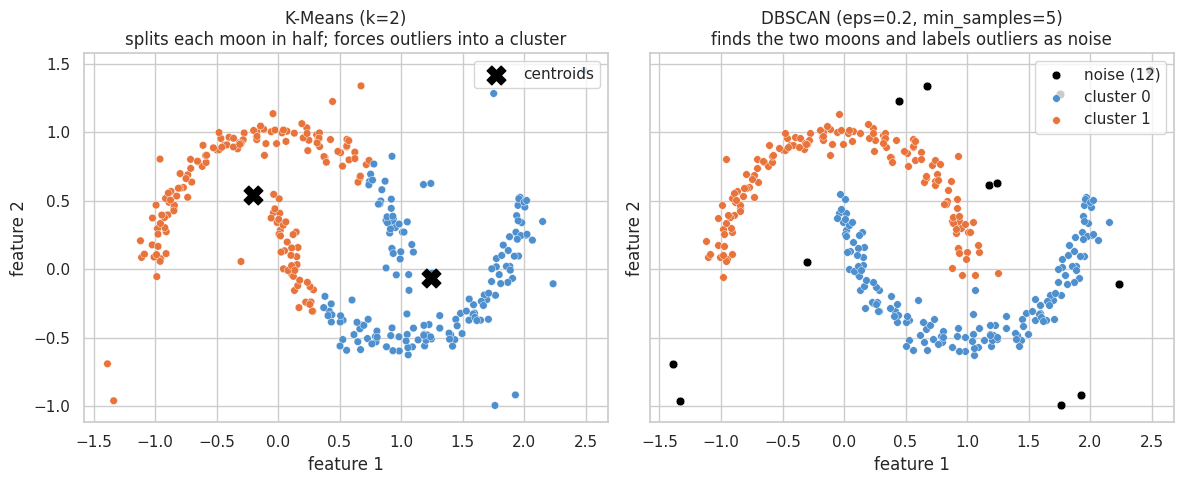

In [2]:
# Two interlocking half-moons + 20 random outliers
X_moons, _ = make_moons(n_samples=300, noise=0.06, random_state=0)
rng        = np.random.default_rng(0)
outliers   = rng.uniform(low=[-1.5, -1.0], high=[2.5, 1.5], size=(20, 2))
X_toy      = np.vstack([X_moons, outliers])

# Fit both algorithms with their natural parameters
km_toy  = KMeans(n_clusters=2, n_init=10, random_state=0).fit(X_toy)
dbs_toy = DBSCAN(eps=0.2, min_samples=5).fit(X_toy)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

# --- K-Means panel ---
palette_km = np.array(["#4E8FCE", "#E8743B"])
axes[0].scatter(X_toy[:, 0], X_toy[:, 1],
                c=palette_km[km_toy.labels_], s=30,
                edgecolor="white", linewidth=0.3)
axes[0].scatter(km_toy.cluster_centers_[:, 0], km_toy.cluster_centers_[:, 1],
                marker="X", s=180, c="black", label="centroids")
axes[0].set_title("K-Means (k=2)\nsplits each moon in half; forces outliers into a cluster")
axes[0].legend(loc="upper right")

# --- DBSCAN panel ---
lbl = dbs_toy.labels_
palette_db = ["#4E8FCE", "#E8743B", "#7FB069"]
for c in sorted(set(lbl)):
    m = lbl == c
    if c == -1:
        axes[1].scatter(X_toy[m, 0], X_toy[m, 1], s=40, c="black",
                        label=f"noise ({m.sum()})", edgecolor="white", linewidth=0.4)
    else:
        axes[1].scatter(X_toy[m, 0], X_toy[m, 1], s=30, c=palette_db[c],
                        label=f"cluster {c}", edgecolor="white", linewidth=0.3)
axes[1].set_title("DBSCAN (eps=0.2, min_samples=5)\n"
                  "finds the two moons and labels outliers as noise")
axes[1].legend(loc="upper right")

for ax in axes:
    ax.set_xlabel("feature 1"); ax.set_ylabel("feature 2")

plt.tight_layout(); plt.show()

Two things to read off the figure:

- **K-Means cannot see the moon shapes.** Its model of a cluster is *points near a centroid*, so it has to split the data with a roughly straight boundary — cutting each crescent in half. And because every point must be assigned, the random outliers are silently absorbed into whichever cluster is closer. There is no way for K-Means to say "this point doesn't fit."
- **DBSCAN follows density.** Each crescent is a density-connected chain, so DBSCAN recovers them as two clusters of arbitrary shape. The random outliers are far from any dense region — they have too few neighbours within `eps` — so DBSCAN explicitly marks them as **noise** (label `-1`).

This is the core reason we're introducing DBSCAN in this notebook. On the real Beijing data we will use DBSCAN *not* to re-discover clusters (K-Means already did that in NB3) but to exploit its **noise label**: any hour whose pollutant + meteorology profile is far from the main density of "normal" hours will be flagged as noise — an **anomaly**.

---
## 4. The `sklearn.cluster.DBSCAN` API

```python
dbs = DBSCAN(eps=1.2, min_samples=10, n_jobs=-1)
labels = dbs.fit_predict(X)   # -1 = noise, 0, 1, ... = clusters
```

Key attributes after fitting:

| Attribute | What it is |
|---|---|
| `dbs.labels_` | `-1` for noise, `0..n` for each cluster. |
| `dbs.core_sample_indices_` | indices of the core points. |
| `dbs.components_` | the core samples themselves. |

There is **no** `predict` method equivalent to K-Means: DBSCAN defines clusters only in terms of the points it has seen. Assigning new points is a separate problem, handled with nearest-neighbour lookups.

---
## 5. Back to Beijing — loading the real data

We work with the same station (Aotizhongxin) and the same 11 numeric features as in NB2 and NB3, standardised in the same way. The one addition compared with the previous notebooks is that we also read the categorical **wind direction** column (`wd`) into our metadata &mdash; we'll need it for the source-apportionment section in §12.

In [3]:
POLLUTANTS = ["PM2.5", "PM10", "SO2", "NO2", "CO", "O3"]
METEO      = ["TEMP", "PRES", "DEWP", "RAIN", "WSPM"]
FEATURES   = POLLUTANTS + METEO

df = pd.read_csv("dataset/PRSA_Data_Aotizhongxin_20130301-20170228.csv")
df["datetime"] = pd.to_datetime(df[["year", "month", "day", "hour"]])

mask = df[FEATURES].notna().all(axis=1)
X    = df.loc[mask, FEATURES].reset_index(drop=True)
meta = df.loc[mask, ["datetime", "month", "hour", "wd"]].reset_index(drop=True)

X_scaled = StandardScaler().fit_transform(X)

print(f"Rows kept:       {len(X):,}")
print(f"Feature matrix:  {X_scaled.shape}")

Rows kept:       31,876
Feature matrix:  (31876, 11)


---
## 6. Why use DBSCAN here? — anomaly detection, not clustering

In the synthetic example DBSCAN recovered two non-spherical clusters *and* flagged outliers. On our real data the clustering part is already solved — K-Means gave us three pollution profiles in Notebook&nbsp;3. Running DBSCAN on the same data would *not* give us three neat clusters, because Beijing hourly measurements form a **single, density-connected continuum** with a few extreme points at its edges.

Instead of fighting that, we lean into it. Run DBSCAN with parameters tuned so that the main continuum ends up as one big cluster, and read the **noise label** as our anomaly detector. That is exactly the setting K-Means cannot handle: it has no concept of "this point doesn't belong anywhere."

We will run DBSCAN in the **11-dimensional standardised feature space** — the same space K-Means used in Notebook&nbsp;3. This keeps anomalies directly interpretable as values in the original pollutant and meteorological features, without an intermediate PCA step.

---
## 7. Picking `eps` from a k-distance plot

A common heuristic for `min_samples` is 2*d*, where *d* is the number of features. With *d* = 11 we pick **`min_samples = 22`**. Given `min_samples`, the standard way to choose `eps` is:

1. For each point, compute the distance to its *k*-th nearest neighbour (where $k = \texttt{min\_samples}$).
2. Sort these distances and plot them.
3. The curve is usually flat for most points and turns sharply upward at the end — the "knee" is a good value for `eps`. Points beyond the knee are those whose *k*-th neighbour is unusually far away, i.e. candidate outliers.

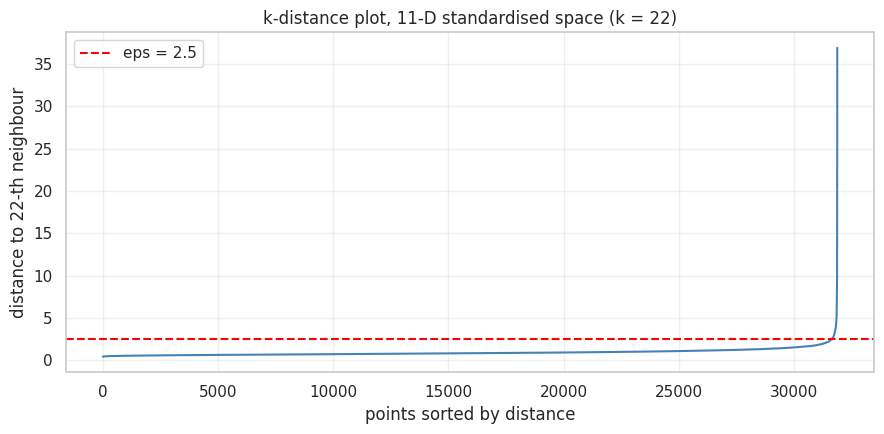

k-distance stats:  median=0.82, 99th percentile=2.31, max=36.93


In [4]:
MIN_SAMPLES = 22

nn = NearestNeighbors(n_neighbors=MIN_SAMPLES).fit(X_scaled)
dists, _ = nn.kneighbors(X_scaled)
kth = np.sort(dists[:, -1])   # distance to the MIN_SAMPLES-th neighbour

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(kth, color="steelblue")
ax.axhline(2.5, color="red", linestyle="--", label="eps = 2.5")
ax.set_xlabel("points sorted by distance")
ax.set_ylabel(f"distance to {MIN_SAMPLES}-th neighbour")
ax.set_title(f"k-distance plot, 11-D standardised space (k = {MIN_SAMPLES})")
ax.grid(alpha=0.3); ax.legend()
plt.tight_layout(); plt.show()

print(f"k-distance stats:  median={np.median(kth):.2f}, "
      f"99th percentile={np.percentile(kth,99):.2f}, max={kth.max():.2f}")

The curve is almost completely flat across the full data set — **most points have their 22-nd nearest neighbour within a distance of about 1** — and then bends sharply upward near the end. That knee is exactly what we are looking for: points to the right of it are the ones whose 22-nd neighbour is unusually far away, i.e. candidates for being flagged as noise.

We will use **`eps = 2.5`** (the red line), which sits just above the 99th percentile of the k-distances — cutting off only the sharply rising tail while keeping the bulk of the data in the dense region.

---
## 8. Fitting DBSCAN

With those parameters chosen, the fit itself is one line. We print cluster sizes and how many points ended up as noise.

In [5]:
EPS = 2.5
dbs = DBSCAN(eps=EPS, min_samples=MIN_SAMPLES, n_jobs=-1).fit(X_scaled)
db_labels = dbs.labels_

counts = pd.Series(db_labels).value_counts().sort_index()
n_clusters = (counts.index >= 0).sum()
n_noise    = int((db_labels == -1).sum())

print(f"eps = {EPS}, min_samples = {MIN_SAMPLES}")
print(f"clusters found (excl. noise): {n_clusters}")
print(f"noise points:                 {n_noise:,}  ({n_noise/len(db_labels)*100:.2f}%)\n")
print("Cluster sizes:")
print(counts.rename("size").to_string())

eps = 2.5, min_samples = 22
clusters found (excl. noise): 1
noise points:                 104  (0.33%)

Cluster sizes:
-1      104
 0    31772


As predicted: DBSCAN reports essentially **one dominant dense region** — the "normal" atmosphere of Aotizhongxin — plus a small fraction (around 0.3–0.4%) of points labelled as noise. That is not a failure of the algorithm. It tells us that hourly measurements do not form well-separated blobs; they form a single continuum with occasional extremes. DBSCAN is correctly pointing out that handful of extremes.

---
## 9. Where do the anomalies sit on physical feature pairs?

We keep the style from Notebook&nbsp;3: instead of projecting onto principal components, we look at the data on a few physically meaningful 2-D slices of the original features. This makes the anomalies readable in familiar units (µg/m³, m/s, °C).

We pick three pairs, each chosen to highlight a different category of anomaly:

- **PM2.5 × TEMP** — extreme-smog hours appear far to the right.
- **PM10 × PM2.5** — dust events stand out *below* the diagonal (PM10 much larger than PM2.5, the coarse-particle signature).
- **CO × WSPM** — stagnation episodes appear at the high-CO / low-wind corner.

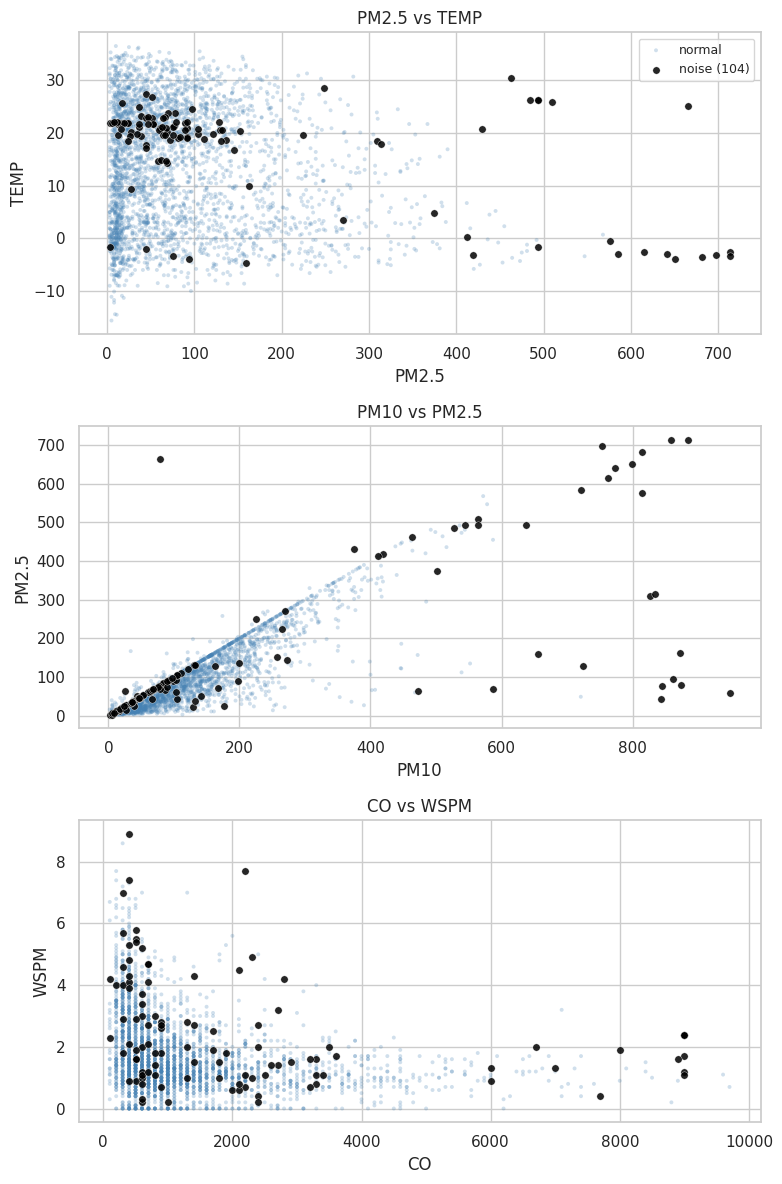

In [6]:
is_noise = db_labels == -1

# Subsample the normal hours for clarity; keep every noise point
idx_norm = np.arange(0, len(X), 10)
idx_norm = idx_norm[~is_noise[idx_norm]]

pairs = [("PM2.5", "TEMP"), ("PM10", "PM2.5"), ("CO", "WSPM")]

fig, axes = plt.subplots(len(pairs), 1, figsize=(8, 4 * len(pairs)))
for ax, (fx, fy) in zip(axes, pairs):
    ax.scatter(X[fx].values[idx_norm], X[fy].values[idx_norm],
               s=8, alpha=0.25, color="steelblue",
               label="normal", edgecolor="none")
    ax.scatter(X[fx].values[is_noise], X[fy].values[is_noise],
               s=28, alpha=0.85, color="black",
               label=f"noise ({int(is_noise.sum())})",
               edgecolor="white", linewidth=0.3)
    ax.set_xlabel(fx); ax.set_ylabel(fy)
    ax.set_title(f"{fx} vs {fy}")

axes[0].legend(loc="upper right", fontsize=9, frameon=True)
plt.tight_layout(); plt.show()

Each panel highlights a different kind of anomaly:

- **PM2.5 × TEMP.** The extreme-smog points (PM2.5 in the hundreds) stretch far to the right of the main blob. **The majority sit at cold temperatures** &mdash; the classic Beijing winter-smog signature &mdash; **with a smaller group at warm temperatures** reflecting occasional severe summer episodes (e.g. late-June 2013).
- **PM10 × PM2.5.** Normal hours lie along the diagonal (PM10 and PM2.5 rise together). **Noise points below the diagonal** — high PM10 with relatively low PM2.5 — are the **dust events**: coarse wind-blown particles that the fine fraction does not reflect.
- **CO × WSPM.** Noise points cluster at the **high-CO, low-wind** corner — the stagnation regime in which emissions accumulate under calm conditions.

### Why no single 2-D view is enough

Look carefully: **some noise points appear right in the middle of a given panel**. A point can look "normal" on PM2.5 × TEMP and still be anomalous because it is far from the density of real hours in CO × WSPM, or in some cross-feature combination that no 2-D plot can show. These are **multivariate anomalies** — we'll come back to them in Section&nbsp;10. Their existence is exactly why DBSCAN was run on the full **11-dimensional** standardised space rather than on any single pair. A 2-D view is useful for reading *some* anomalies in physical terms, but it is always a lossy projection of the full-dimensional picture.

---
## 10. Who are the anomalies?

An anomaly label on its own is not very useful. The real question is: **what are these hours, physically?** Let's categorise the noise points by their most striking feature and see what natural groups emerge.

In [7]:
noise_df = pd.concat([meta, X], axis=1).loc[is_noise].copy()

# Classify each noise point by its most prominent physical signature
def classify(row):
    if row["RAIN"] > 5:                             return "rain washout"
    if row["PM2.5"] > 400:                          return "extreme smog"
    if (row["PM10"] - row["PM2.5"]) > 400:          return "dust / coarse PM"
    return "other"

noise_df["category"] = noise_df.apply(classify, axis=1)

print(noise_df["category"].value_counts().to_string())
print(f"\nTotal noise points: {len(noise_df)}")

category
rain washout        57
extreme smog        18
other               17
dust / coarse PM    12

Total noise points: 104


Three physically distinct categories dominate, with a residual "other" bucket:

- **rain washout** — hours with heavy rainfall (RAIN &gt; 5&nbsp;mm/hr). Rain scavenges particulates; PM collapses to very low values.
- **extreme smog** — PM2.5 above 400&nbsp;µg/m³. Beijing's worst pollution events.
- **dust / coarse PM** — PM10 much greater than PM2.5 (excess of &gt; 400 µg/m³). A signature of wind-blown dust rather than combustion.
- **other** — unusual combinations that don't fit a single clean category (e.g. moderately polluted hours with an unusual meteorology vector).

Let's see one representative example of each:

In [8]:
show_cols = ["datetime", "PM2.5", "PM10", "SO2", "NO2", "CO", "O3",
             "TEMP", "RAIN", "WSPM", "wd", "category"]

# Most extreme example per category
examples = []
if (noise_df["category"] == "extreme smog").any():
    examples.append(noise_df[noise_df["category"] == "extreme smog"]
                    .nlargest(1, "PM2.5"))
if (noise_df["category"] == "rain washout").any():
    examples.append(noise_df[noise_df["category"] == "rain washout"]
                    .nlargest(1, "RAIN"))
if (noise_df["category"] == "dust / coarse PM").any():
    examples.append(noise_df[noise_df["category"] == "dust / coarse PM"]
                    .assign(excess=lambda d: d["PM10"] - d["PM2.5"])
                    .nlargest(1, "excess").drop(columns="excess"))
if (noise_df["category"] == "other").any():
    examples.append(noise_df[noise_df["category"] == "other"].sample(1, random_state=0))

pd.concat(examples)[show_cols].reset_index(drop=True)

,datetime,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,RAIN,WSPM,wd,category
0,2016-02-08 03:00:00,713.00,884.00,229.00,91.00,2100.00,10.00,-2.60,0.00,0.60,W,extreme smog
1,2016-09-11 03:00:00,75.00,75.00,2.00,21.00,600.00,72.00,19.70,46.40,3.40,E,rain washout
2,2014-05-03 20:00:00,58.00,948.00,2.00,7.00,200.00,81.00,14.60,0.00,4.00,N,dust / coarse PM
3,2013-08-11 14:00:00,249.00,226.00,7.00,36.00,1400.00,169.00,28.50,3.60,4.30,NE,other


Each row in this small table is a different *kind* of atmospheric extreme:

- The **extreme smog** example will be a winter or early-summer hour with PM2.5 in the hundreds, CO in the thousands, and low wind speed.
- The **rain washout** example has RAIN in the tens of mm/hour, PM2.5 collapsed to single digits.
- The **dust** example shows PM10 dwarfing PM2.5 — coarse particles dominating the aerosol budget, typical of Gobi-dust transport events.
- The **other** bucket catches odd combinations that don't land in a clean category but are still statistical outliers. We'll look at these in a moment — they are the most interesting ones.

Each category corresponds to a real atmospheric phenomenon. None of them were labelled for us; DBSCAN surfaced them purely on the basis of density, working in the full 11-dimensional standardised space.

### The real payoff — multivariate anomalies

A reasonable question to ask at this point is: *did we actually need DBSCAN?* The first three categories above could have been found by simple **one-variable thresholds**:

- `RAIN > 5` → rain washouts,
- `PM2.5 > 400` → extreme smog,
- `PM10 - PM2.5 > 400` → dust events.

Each of those rules looks at a single feature. If that is the only kind of anomaly we care about, we do not need a density-based algorithm.

DBSCAN earns its keep on the *other* kind of anomaly: hours where **no single feature is unusual on its own**, but the **combination** of values doesn't look like anything in the normal atmosphere. Those are exactly the points sitting in our "other" bucket. Let's look at them.

In [9]:
others = noise_df[noise_df["category"] == "other"].copy()

# For each 'other' point, count how many features are within the [1%, 99%] percentile range
p01, p99 = X.quantile(0.01), X.quantile(0.99)
in_range = ((others[FEATURES] >= p01) & (others[FEATURES] <= p99)).sum(axis=1)
others["features_in_1-99pct_range"] = in_range

# Sort so the most "all-normal-looking" points appear first
others = others.sort_values("features_in_1-99pct_range", ascending=False)
others[show_cols[:-1] + ["features_in_1-99pct_range"]].reset_index(drop=True)

,datetime,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,RAIN,WSPM,wd,features_in_1-99pct_range
0,2016-03-09 14:00:00,270.00,270.00,4.00,6.00,300.00,80.00,3.50,0.00,4.60,NW,11
1,2015-06-06 15:00:00,44.00,104.00,8.00,26.00,6000.00,208.00,27.40,0.00,1.30,SW,11
2,2015-06-06 19:00:00,23.00,129.00,2.00,47.00,6000.00,68.00,21.80,2.60,0.90,NNW,10
3,2013-09-12 22:00:00,224.00,265.00,14.00,158.00,2300.00,1.00,19.60,4.00,1.00,SE,10
4,2015-06-04 17:00:00,69.00,79.00,3.00,47.00,9000.00,82.00,20.20,0.00,2.40,SW,10
5,2015-06-04 21:00:00,64.00,64.00,4.00,46.00,9000.00,87.00,19.60,0.00,1.10,W,10
6,2015-06-04 22:00:00,66.00,66.00,3.00,52.00,9000.00,72.00,19.60,0.00,1.70,WSW,10
7,2015-06-04 19:00:00,60.00,60.00,4.00,50.00,9000.00,88.00,20.60,0.00,2.40,SSW,10
8,2015-06-04 18:00:00,67.00,67.00,5.00,45.00,9000.00,94.00,20.90,0.00,1.20,WSW,10
9,2015-06-06 16:00:00,51.00,141.00,6.00,34.00,7000.00,187.00,26.90,0.10,1.30,NNE,10


Read the rightmost column, **`features_in_1-99pct_range`**: it counts how many of the 11 features sit inside the typical [1st, 99th] percentile band for this station. A value of 11 means *every single measurement at that hour looks normal on its own* — yet DBSCAN still flagged the hour as anomalous because the full 11-D combination is far from any dense region of the data.

A couple of examples worth looking at:

- **2015-06-06 15:00** (all features in the normal [1%, 99%] range). A warm summer afternoon (TEMP = 27&nbsp;°C), modest PM2.5 (44&nbsp;µg/m³), yet CO = 6 000 and O₃ = 208. Individually each value is plausible, but the **joint** pattern — summer-high ozone together with winter-typical CO levels and a normal PM2.5 — does not match any of the three K-Means regimes from Notebook&nbsp;3. A real investigator might check for an upwind industrial CO release that day.
- **2016-03-09 14:00** reports PM2.5 = 270 and PM10 = 270, **exactly equal**. That is physically implausible because coarse particles (PM10) always include the fine fraction (PM2.5), so PM10 ≥ PM2.5 by construction. This looks much more like a **sensor glitch** than an atmospheric event. A simple "PM2.5 &gt; X" alert would never have noticed; a multivariate anomaly detector does.

Other rows in the table show comparable patterns: unexpected decouplings between combustion co-tracers (e.g. CO climbing to 8 000–9 000 µg/m³ while PM2.5 stays in the 40–70 range, as in the consecutive June 2015 hours), suspiciously rounded or repeated values, or rare multi-hour excursions that no univariate filter would flag.

This is the **real reason** to use DBSCAN on a sensor network: it catches *joint* anomalies — faulty instruments, unusual source events, atmospheric conditions that don't fit any known regime — that look perfectly normal when viewed one variable at a time.

A practical consequence of everything above: if you were monitoring this station in real time, DBSCAN-style anomaly flagging would have triggered alerts on exactly these hours — each alert worth investigating (episode response, instrument check, or meteorological correlation).

---
## 11. Source apportionment — hypothesising the origins

So far we have described *what* the pollution looks like (PCA axes), *which regimes* recur (K-Means profiles), and *which hours* are anomalous (DBSCAN). The natural final question is:

> *Where does the pollution come from?*

This is the domain of **source apportionment** — attributing ambient concentrations to specific emission sources (traffic, residential heating, industrial combustion, wind-blown dust, secondary aerosol formation, …).

> **Important honest disclaimer.** Rigorous source apportionment uses specialised receptor-modelling techniques (Positive Matrix Factorisation, Chemical Mass Balance, back-trajectory analysis) and typically also requires measurements of chemical tracers beyond what this dataset provides. What we will do here is use the **unsupervised findings** plus the data's **wind direction** column to build a set of **reasonable source hypotheses**. These are a starting point for more detailed investigation, not a final attribution.

> ⚠️ **Correlation, not causation.** Unsupervised methods reveal *statistical associations* — what moves with what, what is extreme, what directions explain variance. **They do not establish that one thing causes another.** Every component, cluster, or noise point is a *hypothesis* generated from the data, never a proof. Causal claims require domain knowledge, controlled comparisons, or further measurements.

---
## 12. Wind direction as a source-location signal

The simplest tool for guessing the *geographical* origin of pollution is to look at how concentrations depend on the wind direction when each measurement was taken. If PM2.5 is consistently higher when the wind comes from a given sector, there is likely a source upwind in that sector.

We look at two species that tend to carry different source signatures:

- **PM2.5** — a mix of combustion aerosols, secondary organics, and aged pollution; a general "pollution level" tracer.
- **SO₂** — specifically produced by burning **sulphur-containing fuels**, overwhelmingly coal. SO₂ is a classic *coal combustion* tracer.

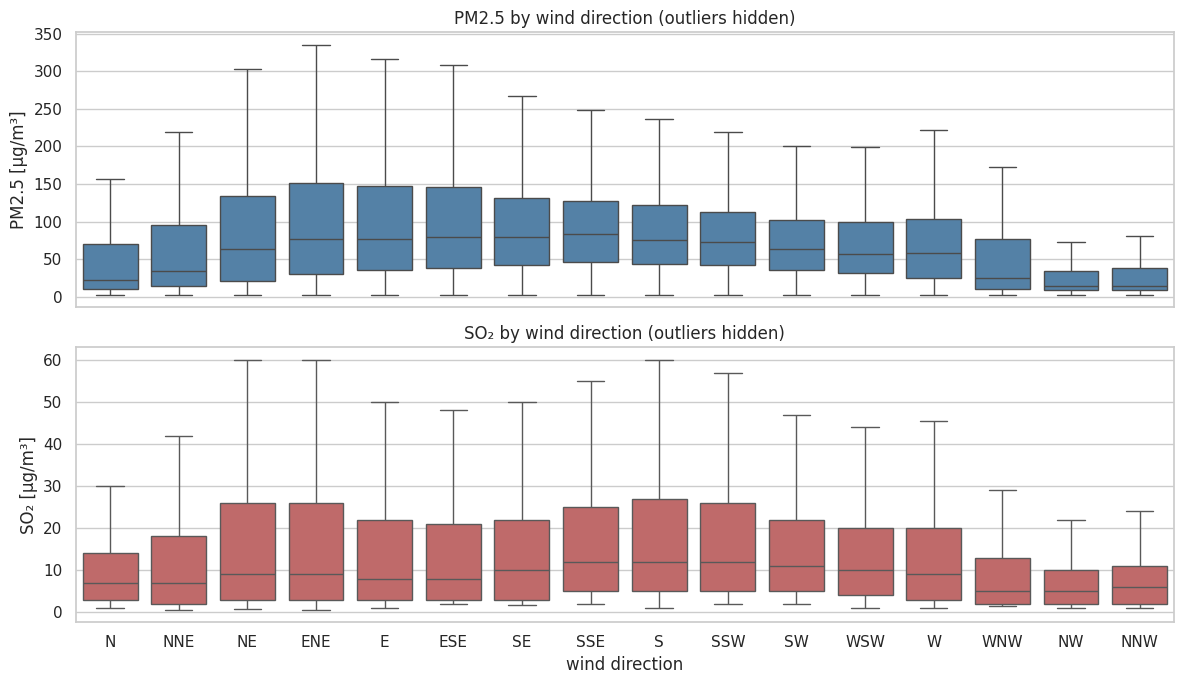

In [10]:
WD_ORDER = ["N", "NNE", "NE", "ENE", "E", "ESE", "SE", "SSE",
            "S", "SSW", "SW", "WSW", "W", "WNW", "NW", "NNW"]

df_wd = pd.concat([meta[["wd"]], X[POLLUTANTS]], axis=1)
df_wd = df_wd[df_wd["wd"].isin(WD_ORDER)]

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

sns.boxplot(data=df_wd, x="wd", y="PM2.5", order=WD_ORDER,
            color="steelblue", showfliers=False, ax=axes[0])
axes[0].set_title("PM2.5 by wind direction (outliers hidden)")
axes[0].set_ylabel("PM2.5 [\u00b5g/m\u00b3]"); axes[0].set_xlabel("")

sns.boxplot(data=df_wd, x="wd", y="SO2", order=WD_ORDER,
            color="indianred", showfliers=False, ax=axes[1])
axes[1].set_title("SO\u2082 by wind direction (outliers hidden)")
axes[1].set_ylabel("SO\u2082 [\u00b5g/m\u00b3]")
axes[1].set_xlabel("wind direction")

plt.tight_layout(); plt.show()

Both panels tell essentially the same geographical story, with SO₂ particularly sharp:

- **Southerly and south-easterly sectors (SE, SSE, S, SSW)** have the highest PM2.5 medians (roughly **75–85 µg/m³**, peaking at SSE) and the longest upper whiskers. SO₂ shows the same peak centred on S–SSW (median ≈ 12 µg/m³).
- **Northern and north-westerly sectors (NW, NNW, N)** have the cleanest conditions — PM2.5 medians around **14–25 µg/m³** and SO₂ medians near 5–7 µg/m³.

The geographical reading is textbook for Beijing: **industrial and coal-burning activity is concentrated south of the city, on the North China Plain**; the mountains to the north typically deliver clean air. The fact that SO₂ peaks more sharply than PM2.5 with southerly winds **strongly supports the hypothesis** that upwind sources tied to coal and industry contribute significantly to SO₂ at Aotizhongxin. Establishing that they are the *dominant* source would require additional evidence beyond the wind rose — none of which our dataset provides.

---
## 13. Bringing it all together — source hypotheses

We now read PCA, K-Means, DBSCAN, and the wind rose *together*, and ask: which emission sources are most consistent with each signal we have observed?

| Source | Evidence we have seen |
|---|---|
| **Local traffic** | PC1 loads strongly on CO + NO₂ together; the winter-smog K-Means cluster shows both surging when wind speed collapses, consistent with accumulation from nearby roads under stagnant conditions. |
| **Domestic / district heating** | PC1's cold-season bias (TEMP loads negatively); the winter-smog cluster has very high CO (≈ 3 000 µg/m³) coincident with cold, calm conditions — a pattern plausibly involving heating-related emissions on top of traffic. |
| **Coal-burning industry (regional)** | SO₂ medians peak with southerly winds (S, SSE, SSW), consistent with upwind sulphur sources on the North China Plain where coal-burning industry is concentrated. |
| **Wind-blown dust** | Several DBSCAN noise points have PM10 >> PM2.5 (excess of hundreds of µg/m³) — a coarse-particle signature very different from the combustion profile and consistent with episodic, long-range transport of mineral dust. |
| **Secondary / photochemistry** | The warm-season K-Means cluster has elevated O₃ (and, at k = 4, a dedicated summer-photochemistry sub-regime with very high O₃ and low PM) — consistent with in-situ ozone production under sunny, warm conditions rather than direct emission. |
| **Precipitation-driven removal** (*not a source; a sink*) | DBSCAN-flagged rain washout hours show PM collapsing during heavy rain — consistent with rain scavenging PM. (PCA gave RAIN its own component (PC4) for a different reason: its bursty, mostly-zero distribution doesn't fit smoothly with any other variable.) |

None of these rows is a quantitative attribution — we never say "traffic accounts for 32% of PM2.5." What we have is a **qualitative, evidence-backed set of source hypotheses**, each supported by multiple independent signals from the data. Our unsupervised analysis has narrowed the search space and identified which hypotheses are worth investigating further with dedicated tools — which is exactly the role unsupervised methods play in real environmental workflows.

---
## 14. Mini-exercise — how sensitive is DBSCAN to `eps`?

DBSCAN's decisions about what is noise depend on the distance threshold `eps`. Intuitively:

- **Smaller `eps`** ⇒ stricter density requirement ⇒ more points fail it ⇒ more noise.
- **Larger `eps`** ⇒ easier to be a neighbour ⇒ fewer noise points ⇒ possibly everything merges.

**Task.** Change `EPS_TRY` below and observe how the counts of clusters and noise points change. Where does the result stop being useful for anomaly detection?

In [11]:
for EPS_TRY in [2.0, 2.3, 2.5, 2.8, 3.0]:
    lab = DBSCAN(eps=EPS_TRY, min_samples=MIN_SAMPLES, n_jobs=-1).fit(X_scaled).labels_
    n_clust = len(set(lab)) - (1 if -1 in lab else 0)
    n_noi   = int((lab == -1).sum())
    print(f"eps = {EPS_TRY:>4}  ->  clusters = {n_clust:>2}, "
          f"noise = {n_noi:>5,}  ({n_noi/len(lab)*100:.2f}%)")

eps =  2.0  ->  clusters =  1, noise =   214  (0.67%)


eps =  2.3  ->  clusters =  1, noise =   125  (0.39%)


eps =  2.5  ->  clusters =  1, noise =   104  (0.33%)


eps =  2.8  ->  clusters =  1, noise =    77  (0.24%)


eps =  3.0  ->  clusters =  1, noise =    69  (0.22%)


You should see:

- At **eps = 2.0**: noise fraction grows toward 0.7% — the algorithm is catching more mild outliers, not just the most extreme ones.
- At **eps = 2.3–2.5**: a single main cluster and a clean anomaly set (roughly 100–130 points, 0.3–0.4%). This is the useful anomaly-detection regime.
- At **eps = 3.0**: the noise fraction drops to ~0.2% — we now miss the milder anomalies, and are left with only the most extreme ones.

**Take-away.** DBSCAN needs parameter tuning guided by the k-distance plot and by the qualitative plausibility of what comes out. It is less automatic than its "no need to choose k" reputation suggests.

---
## Wrap-up — the Module 2 picture

Across four notebooks we used four unsupervised tools to build up a layered understanding of Beijing's hourly air-quality record at Aotizhongxin:

| Notebook | Tool | Question | What we learned |
|---|---|---|---|
| NB1 | (concepts) | What is unsupervised learning? | Tasks, analogies, why labels are rare. |
| NB2 | **PCA** | What are the axes of variability? | Four components: combustion, season, dispersion, rain (83% of variance). |
| NB3 | **K-Means** | What are the typical regimes? | Three pollution profiles; the two winter ones separated by wind speed, not temperature. |
| NB4 | **DBSCAN + wind** | Which hours are anomalous? Where does pollution come from? | Concrete anomalies (smog, rain, dust) plus *multivariate* anomalies invisible to single-variable filters; southerly-wind source signature. |

None of these tools used any labels. Yet together they reconstructed a coherent physical picture of Beijing's air that matches the published literature on the city's pollution dynamics — seasonal combustion, stagnation-driven winter smog, regional coal-burning industry to the south, episodic dust and rain events.

### Common threads

- **Standardise always.** PCA, K-Means, and DBSCAN are all distance-based; unscaled features dominate the result.
- **Interpret, don't just fit.** Components, clusters, and noise points only become useful when we take the time to read them in physical terms.
- **Unsupervised methods generate hypotheses.** They do not prove causation. Results must be cross-checked against domain knowledge and further measurements.
- **Independent validation matters.** The seasonal signal we found in PCA reappeared in K-Means and in DBSCAN-flagged anomalies. Convergence of multiple methods is a much stronger signal than any single fit.

### Check your understanding

1. In one sentence each: what *kind* of question does PCA answer, and what kind does DBSCAN answer?
2. Why does DBSCAN produce only one cluster on this data instead of three like K-Means did?
3. We hypothesised that coal combustion is a major source of SO₂. Which two pieces of evidence from this notebook support that?
4. A colleague says "PC3 is ozone, DBSCAN flagged rainy hours; clearly ozone comes from rain." What is wrong with that chain of reasoning?

*(Answers: 1 — PCA: "what are the dominant axes of variability?"; DBSCAN: "which points don't belong to any dense region?" 2 — the data forms a single density-connected continuum; K-Means is forced to split it anyway, DBSCAN correctly reports it as one dense region. 3 — SO₂ peaks sharply with southerly winds (regional upwind sources) and is specifically associated with burning sulphur-containing fuels (coal). 4 — unsupervised methods reveal statistical associations, not causation. PC3 and PC4 being separate directions, and rainy hours being DBSCAN noise, do not imply any causal link between rain and ozone. Domain knowledge (photochemistry of O₃, scavenging by rain) is what constrains valid interpretations.)*